Starting training on cpu...
Epoch [1/20], Loss: 0.0823
Epoch [2/20], Loss: 0.0636
Epoch [3/20], Loss: 0.0650
Epoch [4/20], Loss: 0.0638
Epoch [5/20], Loss: 0.0619
Epoch [6/20], Loss: 0.1674
Epoch [7/20], Loss: 0.1724
Epoch [8/20], Loss: 0.1692
Epoch [9/20], Loss: 0.1720
Epoch [10/20], Loss: 0.1707
Epoch [11/20], Loss: 0.1700
Epoch [12/20], Loss: 0.1694
Epoch [13/20], Loss: 0.3762
Epoch [14/20], Loss: 0.3814
Epoch [15/20], Loss: 0.4893
Epoch [16/20], Loss: 0.4896
Epoch [17/20], Loss: 0.4887
Epoch [18/20], Loss: 0.4876
Epoch [19/20], Loss: 0.5444
Epoch [20/20], Loss: 0.7024


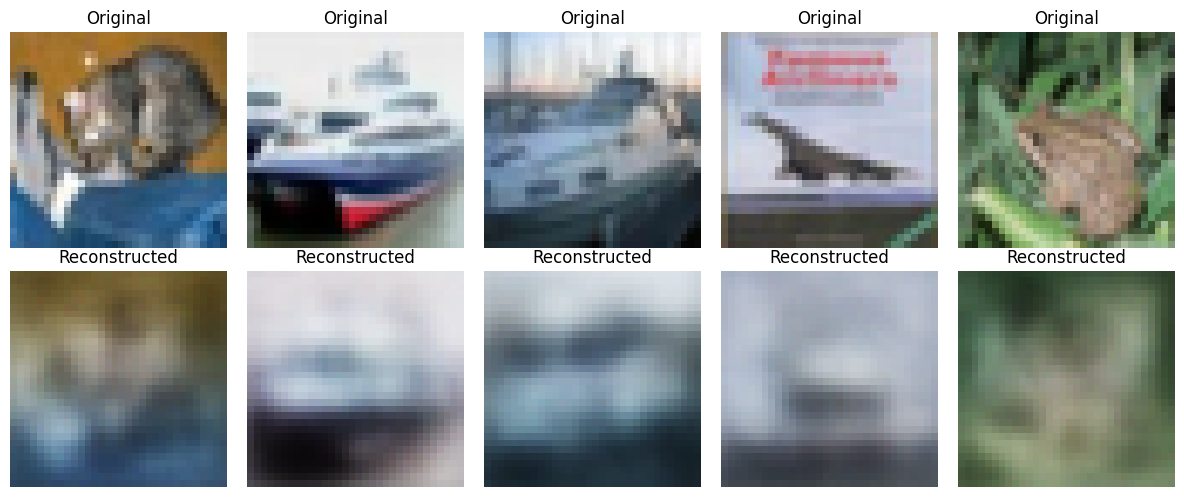

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- 1. Hyperparameters  ---
input_dim = 3072        # 32x32x3
hidden_dim = 512        # Size of the compressed representation
batch_size = 64
learning_rate = 1e-4    # Slower learning rate for stability
epochs = 20
sparsity_target = 0.05  # We want ~5% of neurons to be active
sparsity_weight = 0.01  # Lowered from 0.2 to prevent "dead" layers

# --- 2. Data Loading (Fix: Remove 0.5 Normalization) ---
# ToTensor() scales pixels to [0, 1], matching the Sigmoid output.
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- 3. Model Architecture (Fix: ReLU Encoder) ---
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SparseAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU() # ReLU prevents vanishing gradients better than Sigmoid here
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid() # Sigmoid ensures output is in [0, 1] range
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# --- 4. KL Divergence Function ---
def kl_divergence(rho, rho_hat):
    # Clamping prevents log(0) errors which cause NaNs
    rho_hat = torch.clamp(rho_hat, min=1e-5, max=1-1e-5)
    return rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

# --- 5. Initialization ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SparseAutoencoder(input_dim, hidden_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- 6. Training Loop ---
print(f"Starting training on {device}...")
model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        img = data.view(data.size(0), -1).to(device)

        # Forward pass
        encoded, decoded = model(img)

        # Reconstruction Loss
        mse_loss = criterion(decoded, img)

        # Sparsity Penalty
        rho_hat = torch.mean(encoded, dim=0)
        sparsity_loss = torch.sum(kl_divergence(sparsity_target, rho_hat))

        # Combined Loss
        loss = mse_loss + (sparsity_weight * sparsity_loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

# --- 7. Visualization ---
model.eval()
with torch.no_grad():
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    flat_images = images.view(images.size(0), -1).to(device)
    _, reconstructed = model(flat_images)
    reconstructed = reconstructed.view(-1, 3, 32, 32).cpu()

def show_results(orig, recon, n=5):
    plt.figure(figsize=(12, 5))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(orig[i].permute(1, 2, 0))
        plt.title("Original")
        plt.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i].permute(1, 2, 0))
        plt.title("Reconstructed")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_results(images, reconstructed)